# Project - Predictive Modeling

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score
import math

## Problem 1: Linear Regression

## You are hired by a company Gem Stones co ltd, which is a cubic zirconia manufacturer. You are provided with the dataset containing the prices and other attributes of almost 27,000 cubic zirconia (which is an inexpensive diamond alternative with many of the same qualities as a diamond). The company is earning different profits on different prize slots. You have to help the company in predicting the price for the stone on the bases of the details given in the dataset so it can distinguish between higher profitable stones and lower profitable stones so as to have better profit share. Also, provide them with the best 5 attributes that are most important.

## Dataset for Problem 1: cubic_zirconia.csv

## 1.1. Read the data and do exploratory data analysis. Describe the data briefly. (Check the null values, Data types, shape, EDA). Perform Univariate and Bivariate Analysis.	

### Ans:

In [3]:
df1 = pd.read_csv('cubic_zirconia.csv')

In [4]:
df1.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,x,y,z,price
0,1,0.30,Ideal,E,SI1,62.1,58.0,4.27,4.29,2.66,499
1,2,0.33,Premium,G,IF,60.8,58.0,4.42,4.46,2.70,984
2,3,0.90,Very Good,E,VVS2,62.2,60.0,6.04,6.12,3.78,6289
3,4,0.42,Ideal,F,VS1,61.6,56.0,4.82,4.80,2.96,1082
4,5,0.31,Ideal,F,VVS1,60.4,59.0,4.35,4.43,2.65,779


In [5]:
df1.shape

(26967, 11)

In [6]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26967 entries, 0 to 26966
Data columns (total 11 columns):
Unnamed: 0    26967 non-null int64
carat         26967 non-null float64
cut           26967 non-null object
color         26967 non-null object
clarity       26967 non-null object
depth         26270 non-null float64
table         26967 non-null float64
x             26967 non-null float64
y             26967 non-null float64
z             26967 non-null float64
price         26967 non-null int64
dtypes: float64(6), int64(2), object(3)
memory usage: 2.3+ MB


In [7]:
df1.describe(include='all')

,Unnamed: 0,carat,cut,color,clarity,depth,table,x,y,z,price
count,26967.000000,26967.000000,26967,26967,26967,26270.000000,26967.000000,26967.000000,26967.000000,26967.000000,26967.000000
unique,NaN,NaN,5,7,8,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Ideal,G,SI1,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,10816,5661,6571,NaN,NaN,NaN,NaN,NaN,NaN
mean,13484.000000,0.798375,NaN,NaN,NaN,61.745147,57.456080,5.729854,5.733569,3.538057,3939.518115
std,7784.846691,0.477745,NaN,NaN,NaN,1.412860,2.232068,1.128516,1.166058,0.720624,4024.864666
min,1.000000,0.200000,NaN,NaN,NaN,50.800000,49.000000,0.000000,0.000000,0.000000,326.000000
25%,6742.500000,0.400000,NaN,NaN,NaN,61.000000,56.000000,4.710000,4.710000,2.900000,945.000000
50%,13484.000000,0.700000,NaN,NaN,NaN,61.800000,57.000000,5.690000,5.710000,3.520000,2375.000000
75%,20225.500000,1.050000,NaN,NaN,NaN,62.500000,59.000000,6.550000,6.540000,4.040000,5360.000000


In [8]:
df1.isna().sum()

Unnamed: 0      0
carat           0
cut             0
color           0
clarity         0
depth         697
table           0
x               0
y               0
z               0
price           0
dtype: int64

In [9]:
dups = df1.duplicated().sum()
dups

0

In [10]:
df1.dtypes

Unnamed: 0      int64
carat         float64
cut            object
color          object
clarity        object
depth         float64
table         float64
x             float64
y             float64
z             float64
price           int64
dtype: object

In [11]:
df1.quantile(0.75)-df1.quantile(0.25)

Unnamed: 0    13483.00
carat             0.65
depth             1.50
table             3.00
x                 1.84
y                 1.83
z                 1.14
price          4415.00
dtype: float64

In [12]:
df1.var()

Unnamed: 0    6.060384e+07
carat         2.282407e-01
depth         1.996174e+00
table         4.982127e+00
x             1.273549e+00
y             1.359690e+00
z             5.192984e-01
price         1.619954e+07
dtype: float64

In [13]:
df1.skew()

Unnamed: 0    0.000000
carat         1.116481
depth        -0.028618
table         0.765758
x             0.387986
y             3.850189
z             2.568257
price         1.618550
dtype: float64

(array([1, 2, 3, 4, 5, 6, 7, 8]), <a list of 8 Text xticklabel objects>)

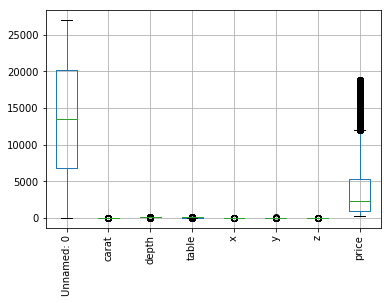

In [15]:
df1.boxplot()
plt.xticks(rotation=90)

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x0000003E8426D400>,
      dtype=object)

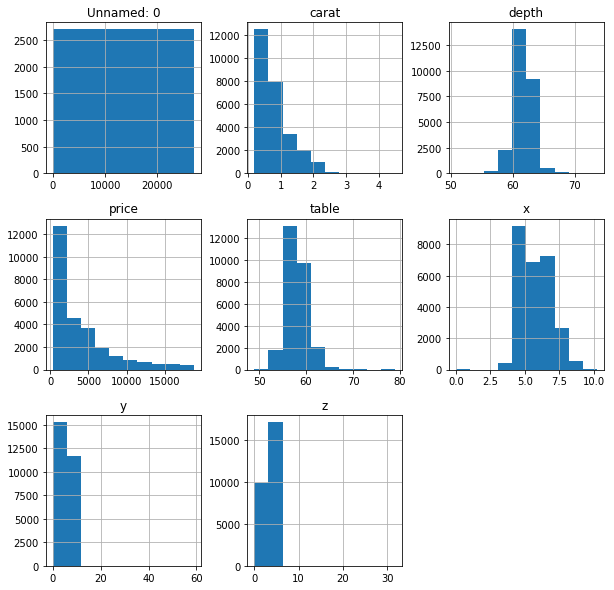

In [16]:
df1.hist(figsize=(10,10))

In [ ]:
sns.pairplot(df1)

In [20]:
df1.cov()

,Unnamed: 0,carat,depth,table,x,y,z,price
Unnamed: 0,6.060384e+07,12.978981,-17.458374,66.324405,40.641354,62.130324,9.429493,8.304578e+04
carat,1.297898e+01,0.228241,0.023844,0.193742,0.526403,0.524250,0.323839,1.773678e+03
depth,-1.745837e+01,0.023844,1.996174,-0.939265,-0.029813,-0.040760,0.100411,-1.459691e+01
table,6.632440e+01,0.193742,-0.939265,4.982127,0.494228,0.474596,0.239574,1.140420e+03
x,4.064135e+01,0.526403,-0.029813,0.494228,1.273549,1.266851,0.777946,4.025446e+03
y,6.213032e+01,0.524250,-0.040760,0.474596,1.266851,1.359690,0.780563,4.018538e+03
z,9.429493e+00,0.323839,0.100411,0.239574,0.777946,0.780563,0.519298,2.466906e+03
price,8.304578e+04,1773.677848,-14.596911,1140.419986,4025.446081,4018.537829,2466.905683,1.619954e+07


In [21]:
df1.corr()

,Unnamed: 0,carat,depth,table,x,y,z,price
Unnamed: 0,1.000000,0.003490,-0.001588,0.003817,0.004626,0.006844,0.001681,0.002650
carat,0.003490,1.000000,0.035364,0.181685,0.976368,0.941071,0.940640,0.922416
depth,-0.001588,0.035364,1.000000,-0.298011,-0.018715,-0.024735,0.101624,-0.002569
table,0.003817,0.181685,-0.298011,1.000000,0.196206,0.182346,0.148944,0.126942
x,0.004626,0.976368,-0.018715,0.196206,1.000000,0.962715,0.956606,0.886247
y,0.006844,0.941071,-0.024735,0.182346,0.962715,1.000000,0.928923,0.856243
z,0.001681,0.940640,0.101624,0.148944,0.956606,0.928923,1.000000,0.850536
price,0.002650,0.922416,-0.002569,0.126942,0.886247,0.856243,0.850536,1.000000


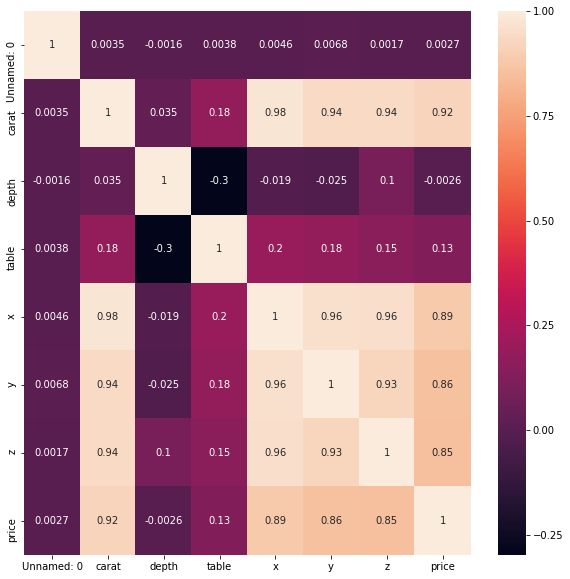

In [22]:
plt.figure(figsize=(10,10))
sns.heatmap(df1.corr(), annot = True)

### From the pairplot and Heatmap, we can infer that:
### The dimensions- length, width and height of cubic zirconia are highly correlated with each other.
### The 3 dimensions of Cubic zirconia are highly correlated with the carat.
### We can also observe that there is high correlation between the dimensions, carat with the price of cubic zirconia.

## 1.2 Impute null values if present, also check for the values which are equal to zero. Do they have any meaning or do we need to change them or drop them? Do you think scaling is necessary in this case?	

### Ans:

#### Checking for null values

In [23]:
df1.isnull().sum()

Unnamed: 0      0
carat           0
cut             0
color           0
clarity         0
depth         697
table           0
x               0
y               0
z               0
price           0
dtype: int64

### From the above output we can see that, there are 697 null values in the column variable Depth

In [24]:
df1.depth.mean()

61.745146555006194

In [25]:
df1.depth.median()

61.8

### As per above result, we can see that Mean and Median values computed are almost equal. As Median is less affected by Outliers, we will go ahead with Median imputation. 

In [26]:
df1.depth.fillna(value = df1.depth.median(), inplace=True)

In [27]:
df1.isnull().sum()

Unnamed: 0    0
carat         0
cut           0
color         0
clarity       0
depth         0
table         0
x             0
y             0
z             0
price         0
dtype: int64

### In the above result, we can see that the null values are successfully imputed.

#### Checking for 0 values in dataset

In [28]:
df1[(df1 == 0).any(axis=1)]

,Unnamed: 0,carat,cut,color,clarity,depth,table,x,y,z,price
5821,5822,0.71,Good,F,SI2,64.1,60.0,0.00,0.00,0.0,2130
6034,6035,2.02,Premium,H,VS2,62.7,53.0,8.02,7.95,0.0,18207
6215,6216,0.71,Good,F,SI2,64.1,60.0,0.00,0.00,0.0,2130
10827,10828,2.20,Premium,H,SI1,61.2,59.0,8.42,8.37,0.0,17265
12498,12499,2.18,Premium,H,SI2,59.4,61.0,8.49,8.45,0.0,12631
12689,12690,1.10,Premium,G,SI2,63.0,59.0,6.50,6.47,0.0,3696
17506,17507,1.14,Fair,G,VS1,57.5,67.0,0.00,0.00,0.0,6381
18194,18195,1.01,Premium,H,I1,58.1,59.0,6.66,6.60,0.0,3167
23758,23759,1.12,Premium,G,I1,60.4,59.0,6.71,6.67,0.0,2383


### As we can see from the above table, number of data rows having 0 as value is 9, which is a very small amount of data. Also, cubic zirconia with a length, width and height of 0 does not make any sense. Hence we will drop the rows containing 0.

In [29]:
df1.replace(0, np.nan, inplace=True)

In [30]:
df1.dropna(inplace=True)

In [31]:
df1.shape

(26958, 11)

### As per above shape, we can see that the 0 values have been replaced by Nan and successfully dropped.

### The independent attributes have different units and scales of measurement 
### It is always a good practice to scale all the dimensions using z scores or some other method to address the problem of different scales

### Please Note: The data will be scaled in the next step

## 1.3 Encode the data (having string values) for Modelling. Data Split: Split the data into test and train (70:30). Apply Linear regression. Performance Metrics: Check the performance of Predictions on Train and Test sets using Rsquare, RMSE.	

### Ans:

#### Dropping the unwanted columns- Unnamed: 0

In [32]:
df1 = df1.drop('Unnamed: 0', axis = 1)

In [33]:
df1.shape

(26958, 10)

#### Encoding the Data having string values

In [34]:
for feature in df1:
    if df1[feature].dtype == 'object':
        df1[feature] = pd.Categorical(df1[feature]).codes

In [35]:
df1.dtypes

carat      float64
cut           int8
color         int8
clarity       int8
depth      float64
table      float64
x          float64
y          float64
z          float64
price        int64
dtype: object

#### Scaling the Dataset using Zscore technique

In [36]:
df1 = df1.apply(zscore)

In [37]:
df1.describe(include='all')

,carat,cut,color,clarity,depth,table,x,y,z,price
count,2.695800e+04,2.695800e+04,2.695800e+04,2.695800e+04,2.695800e+04,2.695800e+04,2.695800e+04,2.695800e+04,2.695800e+04,2.695800e+04
mean,-2.456015e-16,-2.486182e-16,-8.305875e-17,3.975849e-17,6.006524e-15,1.981245e-15,-5.188207e-16,4.517617e-16,3.183479e-16,-5.848665e-17
std,1.000019e+00,1.000019e+00,1.000019e+00,1.000019e+00,1.000019e+00,1.000019e+00,1.000019e+00,1.000019e+00,1.000019e+00,1.000019e+00
min,-1.252508e+00,-2.494429e+00,-1.527362e+00,-2.222894e+00,-7.852672e+00,-3.789618e+00,-1.775199e+00,-1.738209e+00,-3.439892e+00,-8.978512e-01
25%,-8.337419e-01,-5.416247e-01,-9.412463e-01,-1.063314e+00,-4.639527e-01,-6.522727e-01,-9.053968e-01,-8.771918e-01,-8.905219e-01,-7.439968e-01
50%,-2.055928e-01,-5.416247e-01,2.309850e-01,9.626603e-02,3.819328e-02,-2.040806e-01,-3.559496e-02,-2.905721e-02,-2.680104e-02,-3.885659e-01
75%,5.272479e-01,4.347775e-01,8.171006e-01,6.760560e-01,5.403392e-01,6.923038e-01,7.277005e-01,6.923940e-01,6.976100e-01,3.528680e-01
max,7.750963e+00,1.411180e+00,1.989332e+00,1.835636e+00,8.502940e+00,9.656147e+00,3.993895e+00,4.566285e+01,3.937002e+01,3.698393e+00


### As we can see from the above output, we can infer that the Z-score is applied successfully and mean is approximately equal to 0 and Standard Deviation is approximately equal to 1.

#### Splitting the data into Independent and Dependent Variables

In [38]:
X = df1.drop("price", axis=1)
y = df1.pop("price")

#### Splitting the dataset into train-test (70:30)

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.30, random_state=0)

In [40]:
print('X_train',X_train.shape)
print('X_test',X_test.shape)
print('y_train',y_train.shape)
print('y_test',y_test.shape)

X_train (18870, 9)
X_test (8088, 9)
y_train (18870,)
y_test (8088,)


#### Applying Linear Regression

In [41]:
regression_model = LinearRegression()
regression_model.fit(X_train, y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=1, normalize=False)

#### Let us explore the coefficients for each of the independent attributes

In [42]:
for idx, col_name in enumerate(X_train.columns):
    print("The coefficient for {} is {}".format(col_name, regression_model.coef_[idx]))

The coefficient for carat is 1.324689218191229
The coefficient for cut is 0.013093459981448995
The coefficient for color is -0.11889912715564037
The coefficient for clarity is 0.12694000574241993
The coefficient for depth is -0.05500369475854901
The coefficient for table is -0.05247246240094651
The coefficient for x is -0.33171719200557825
The coefficient for y is 0.0017697139195368083
The coefficient for z is -0.007403794992948794


In [43]:
intercept = regression_model.intercept_

print("The intercept for our model is {}".format(intercept))

The intercept for our model is 2.8253356085592004e-06


#### Performance on predictions on train and test using R-square and RMSE

#### R^2 for train data

In [44]:
regression_model.score(X_train, y_train)

0.8856461365747297

#### R^2 for test data

In [45]:
regression_model.score(X_test, y_test)

0.8917578457722393

#### RMSE for train data

In [46]:
mse_train = np.mean((regression_model.predict(X_train)-y_train)**2)
mse_train

0.11404075266449842

In [47]:
rmse_train = math.sqrt(mse_train)
rmse_train

0.3376992044179234

#### RMSE for test data

In [48]:
mse_test = np.mean((regression_model.predict(X_test)-y_test)**2)
mse_test

0.10893329010011006

In [49]:
rmse_test = math.sqrt(mse_test)
rmse_test

0.33005043569144105

## 1.4 Inference: Basis on these predictions, what are the business insights and recommendations.

### Ans:

### 1) The best 5 attributes that are most important as per our model are as follows : carat, x, clarity, color, depth.
### 2) From the correlation between the variables, we can see that the Price is highly correlated with Carat and the 3 dimensions of the cubic zirconia.
### 3) We can observe that the cubic zirconia with higher and bigger dimensions and higher carat provide have better profit share. 


## Problem 2: Logistic Regression and LDA

## You are hired by a tour and travel agency which deals in selling holiday packages. You are provided details of 872 employees of a company. Among these employees, some opted for the package and some didn't. You have to help the company in predicting whether an employee will opt for the package or not on the basis of the information given in the data set. Also, find out the important factors on the basis of which the company will focus on particular employees to sell their packages.

## Dataset for Problem 2: Holiday_Package.csv

## 2.1 Data Ingestion: Read the dataset. Do the descriptive statistics and do null value condition check, write an inference on it. Perform Univariate and Bivariate Analysis. Do exploratory data analysis.

### Ans:

In [2]:
df2 = pd.read_csv('Holiday_Package.csv')

In [3]:
df2.head()

,Unnamed: 0,Holliday_Package,Salary,age,educ,no_young_children,no_older_children,foreign
0,1,no,48412,30,8,1,1,no
1,2,yes,37207,45,8,0,1,no
2,3,no,58022,46,9,0,0,no
3,4,no,66503,31,11,2,0,no
4,5,no,66734,44,12,0,2,no


In [4]:
df2.shape

(872, 8)

In [5]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 872 entries, 0 to 871
Data columns (total 8 columns):
Unnamed: 0           872 non-null int64
Holliday_Package     872 non-null object
Salary               872 non-null int64
age                  872 non-null int64
educ                 872 non-null int64
no_young_children    872 non-null int64
no_older_children    872 non-null int64
foreign              872 non-null object
dtypes: int64(6), object(2)
memory usage: 54.6+ KB


In [6]:
df2.describe(include='all')

,Unnamed: 0,Holliday_Package,Salary,age,educ,no_young_children,no_older_children,foreign
count,872.000000,872,872.000000,872.000000,872.000000,872.000000,872.000000,872
unique,NaN,2,NaN,NaN,NaN,NaN,NaN,2
top,NaN,no,NaN,NaN,NaN,NaN,NaN,no
freq,NaN,471,NaN,NaN,NaN,NaN,NaN,656
mean,436.500000,NaN,47729.172018,39.955275,9.307339,0.311927,0.982798,NaN
std,251.869014,NaN,23418.668531,10.551675,3.036259,0.612870,1.086786,NaN
min,1.000000,NaN,1322.000000,20.000000,1.000000,0.000000,0.000000,NaN
25%,218.750000,NaN,35324.000000,32.000000,8.000000,0.000000,0.000000,NaN
50%,436.500000,NaN,41903.500000,39.000000,9.000000,0.000000,1.000000,NaN
75%,654.250000,NaN,53469.500000,48.000000,12.000000,0.000000,2.000000,NaN


In [7]:
df2.isna().sum()

Unnamed: 0           0
Holliday_Package     0
Salary               0
age                  0
educ                 0
no_young_children    0
no_older_children    0
foreign              0
dtype: int64

In [8]:
df2.duplicated().sum()

0

In [9]:
df2.quantile(0.75) - df2.quantile(0.25)

Unnamed: 0             435.5
Salary               18145.5
age                     16.0
educ                     4.0
no_young_children        0.0
no_older_children        2.0
dtype: float64

In [10]:
df2.var()

Unnamed: 0           6.343800e+04
Salary               5.484340e+08
age                  1.113378e+02
educ                 9.218867e+00
no_young_children    3.756096e-01
no_older_children    1.181104e+00
dtype: float64

In [11]:
df2.skew()

Unnamed: 0           0.000000
Salary               3.103216
age                  0.146412
educ                -0.045501
no_young_children    1.946515
no_older_children    0.953951
dtype: float64

(array([1, 2, 3, 4, 5, 6]), <a list of 6 Text xticklabel objects>)

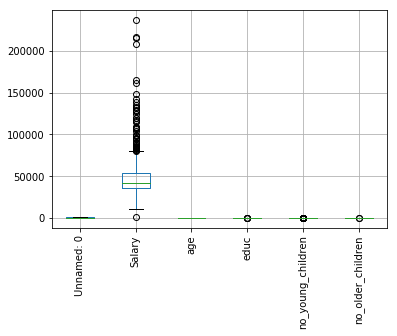

In [12]:
df2.boxplot()
plt.xticks(rotation=90)

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x0000004F2CCF6C18>,
      dtype=object)

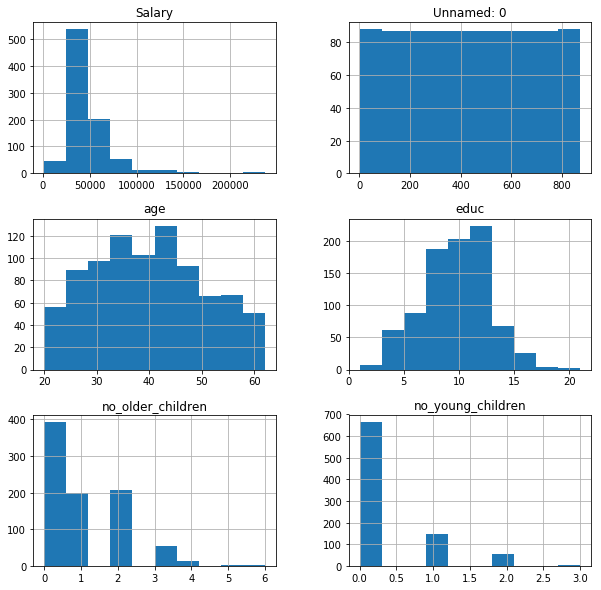

In [13]:
df2.hist(figsize=(10,10))

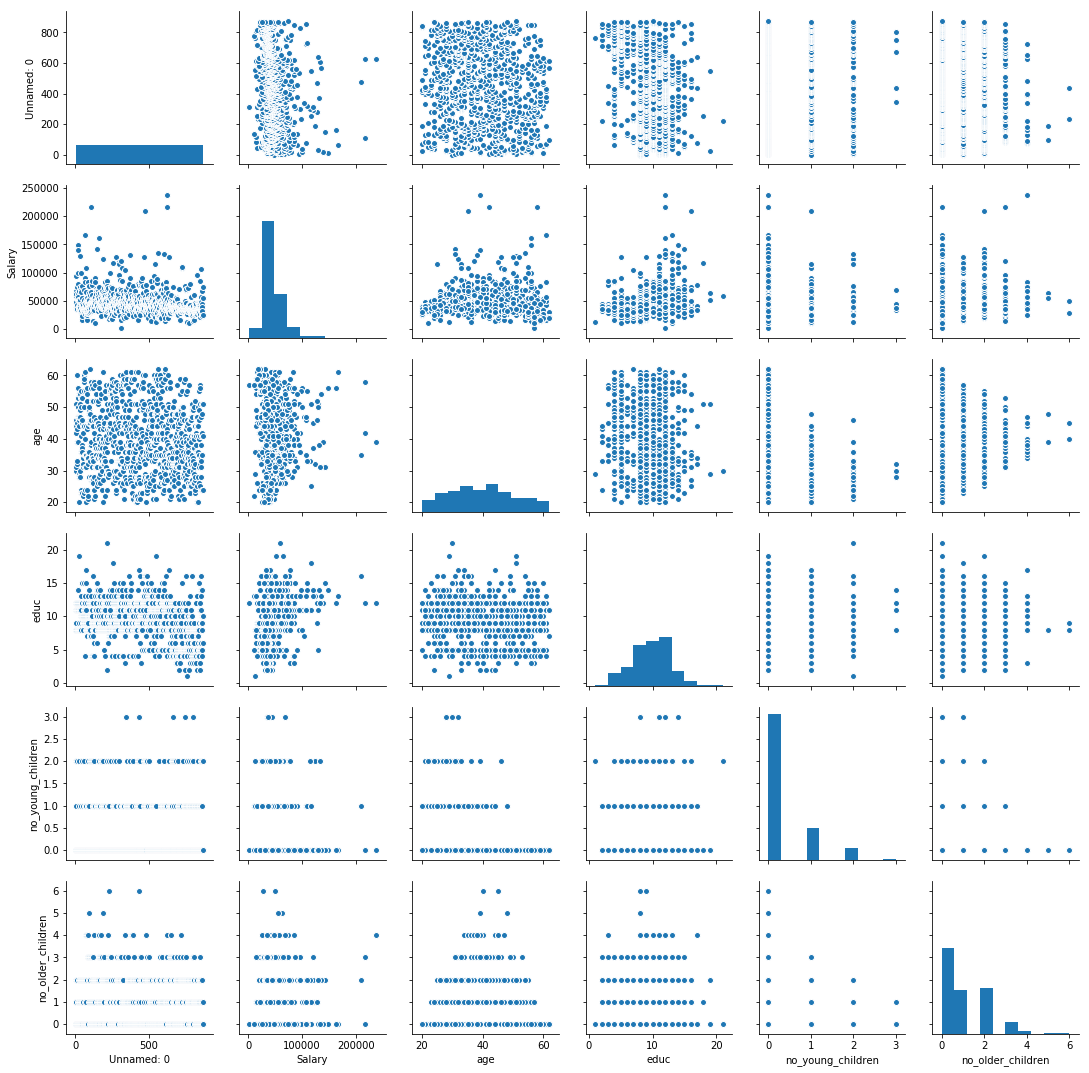

In [14]:
sns.pairplot(df2)

In [15]:
df2.cov()

,Unnamed: 0,Salary,age,educ,no_young_children,no_older_children
Unnamed: 0,6.343800e+04,-1.139867e+06,-275.815729,-226.374282,8.049369,-7.076349
Salary,-1.139867e+06,5.484340e+08,17719.779229,23218.662341,-425.752915,2895.613755
age,-2.758157e+02,1.771978e+04,111.337837,-4.783024,-3.356871,-1.332573
educ,-2.263743e+02,2.321866e+04,-4.783024,9.218867,0.183012,-0.119851
no_young_children,8.049369e+00,-4.257529e+02,-3.356871,0.183012,0.375610,-0.158807
no_older_children,-7.076349e+00,2.895614e+03,-1.332573,-0.119851,-0.158807,1.181104


In [16]:
df2.corr()

,Unnamed: 0,Salary,age,educ,no_young_children,no_older_children
Unnamed: 0,1.000000,-0.193249,-0.103782,-0.296015,0.052146,-0.025852
Salary,-0.193249,1.000000,0.071709,0.326540,-0.029664,0.113772
age,-0.103782,0.071709,1.000000,-0.149294,-0.519093,-0.116205
educ,-0.296015,0.326540,-0.149294,1.000000,0.098350,-0.036321
no_young_children,0.052146,-0.029664,-0.519093,0.098350,1.000000,-0.238428
no_older_children,-0.025852,0.113772,-0.116205,-0.036321,-0.238428,1.000000


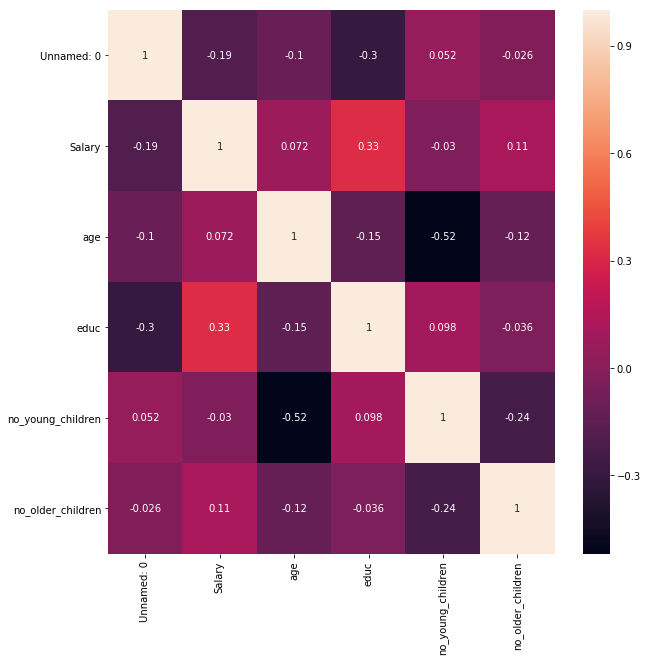

In [17]:
plt.figure(figsize=(10,10))
sns.heatmap(df2.corr(), annot=True)

### From the above pairplot and heatmap, we can infer that:
### The independent variables are not much correlated with each other.
### The age and no of young children are negatively correlated.
### There is a very small positive correlation of education with Salary(0.33) and a small negative correlation of number of older children with Salary(-0.24).

### There are no null values in the dataset

## 2.2 Do not scale the data. Encode the data (having string values) for Modelling. Data Split: Split the data into train and test (70:30). Apply Logistic Regression and LDA (linear discriminant analysis).

### Ans:

In [18]:
df2.dtypes

Unnamed: 0            int64
Holliday_Package     object
Salary                int64
age                   int64
educ                  int64
no_young_children     int64
no_older_children     int64
foreign              object
dtype: object

#### Dropping the unwanted Variables- Unnamed: 0

In [19]:
df2.drop('Unnamed: 0',axis=1, inplace=True)

#### Encoding the data having string values

In [20]:
for feature in df2.columns:
    if df2[feature].dtypes == 'object':
        df2[feature]=pd.Categorical(df2[feature]).codes

In [21]:
df2.dtypes

Holliday_Package      int8
Salary               int64
age                  int64
educ                 int64
no_young_children    int64
no_older_children    int64
foreign               int8
dtype: object

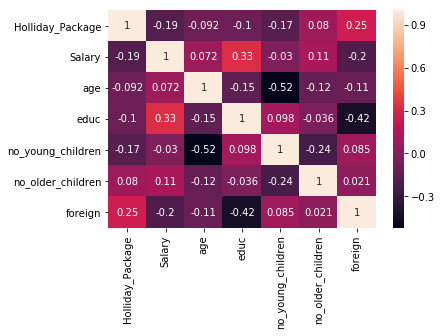

In [23]:
sns.heatmap(df2.corr(), annot=True)

### From the above heatmap, we can infer that:
### 1) Foreign and Holiday package have a positive correlation(0.25)
### 2) Other factors do not show much correlation with the output variable.

#### Splitting the data into Independent and Dependent Variables

In [70]:
X = df2.drop('Holliday_Package', axis = 1)
y= df2.pop('Holliday_Package')

#### Splitting the data into train and test (70:30)

In [71]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30, random_state = 0)

#### Applying Logistic Regression

In [72]:
log_reg_model = LogisticRegression()

In [73]:
log_reg_model.fit(X_train,y_train)

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
          intercept_scaling=1, max_iter=100, multi_class='ovr', n_jobs=1,
          penalty='l2', random_state=None, solver='liblinear', tol=0.0001,
          verbose=0, warm_start=False)

#### Using Logistic Regression Model, perform Predictions on train and test dataset

In [74]:
log_reg_pred_train = log_reg_model.predict(X_train)
log_reg_pred_test = log_reg_model.predict(X_test)

#### Applying Linear Discriminant Analysis

In [75]:
lda = LinearDiscriminantAnalysis()

In [76]:
lda.fit(X_train,y_train)

LinearDiscriminantAnalysis(n_components=None, priors=None, shrinkage=None,
              solver='svd', store_covariance=False, tol=0.0001)

#### Using the LDA Model, perform Predictions on train and test dataset

In [77]:
lda_pred_train = lda.predict(X_train)
lda_pred_test = lda.predict(X_test)

## 2.3 Performance Metrics: Check the performance of Predictions on Train and Test sets using Accuracy, Confusion Matrix, Plot ROC curve and get ROC_AUC score for each model Final Model: Compare Both the models and write inference which model is best/optimized.

### Ans:

#### Performance Metrics based on Logistic Regression Model

#### Accuracy Score on train and test respectively

In [78]:
accuracy_score(y_train, log_reg_pred_train)

0.5639344262295082

In [79]:
accuracy_score(y_test, log_reg_pred_test)

0.4847328244274809

#### Confusion matrix on train and test respectively

In [80]:
confusion_matrix(y_train, log_reg_pred_train)

array([[343,   1],
       [265,   1]], dtype=int64)

In [81]:
confusion_matrix(y_test, log_reg_pred_test)

array([[126,   1],
       [134,   1]], dtype=int64)

#### Classification Report on train and test respectively

In [82]:
print(classification_report(y_train, log_reg_pred_train))

             precision    recall  f1-score   support

          0       0.56      1.00      0.72       344
          1       0.50      0.00      0.01       266

avg / total       0.54      0.56      0.41       610



In [83]:
print(classification_report(y_test, log_reg_pred_test))

             precision    recall  f1-score   support

          0       0.48      0.99      0.65       127
          1       0.50      0.01      0.01       135

avg / total       0.49      0.48      0.32       262



#### ROC-AUC Score on train and test respectively

In [84]:
roc_auc_score(y_train, log_reg_pred_train)

0.5004262108760272

In [85]:
roc_auc_score(y_test, log_reg_pred_test)

0.4997666958296879

#### AUC Curve on train and test respectively

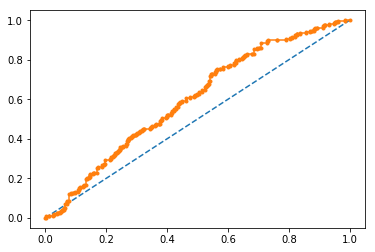

In [86]:
fpr_train_log_reg, tpr_train_log_reg, tresholds_train_log_reg = roc_curve(y_train, log_reg_model.predict_proba(X_train)[:,1])
plt.plot([0,1], [0,1], linestyle='--')
plt.plot(fpr_train_log_reg, tpr_train_log_reg, marker='.')

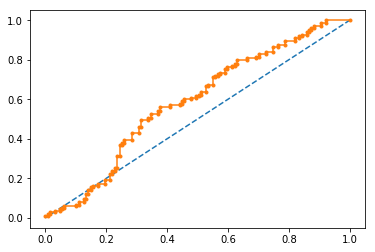

In [87]:
fpr_test_log_reg, tpr_test_log_reg, tresholds_test_log_reg = roc_curve(y_test, log_reg_model.predict_proba(X_test)[:,1])
plt.plot([0,1], [0,1], linestyle='--')
plt.plot(fpr_test_log_reg, tpr_test_log_reg, marker='.')

#### Performance Metrics based on LDA

#### Accuracy Score on train and test respectively

In [88]:
accuracy_score(y_train, lda_pred_train)

0.6836065573770492

In [89]:
accuracy_score(y_test, lda_pred_test)

0.6145038167938931

#### Confusion matrix on train and test respectively

In [90]:
confusion_matrix(y_train, lda_pred_train)

array([[279,  65],
       [128, 138]], dtype=int64)

In [91]:
confusion_matrix(y_test, lda_pred_test)

array([[102,  25],
       [ 76,  59]], dtype=int64)

#### Classification Report on train and test respectively

In [92]:
print(classification_report(y_train, lda_pred_train))

             precision    recall  f1-score   support

          0       0.69      0.81      0.74       344
          1       0.68      0.52      0.59       266

avg / total       0.68      0.68      0.68       610



In [93]:
print(classification_report(y_test, lda_pred_test))

             precision    recall  f1-score   support

          0       0.57      0.80      0.67       127
          1       0.70      0.44      0.54       135

avg / total       0.64      0.61      0.60       262



#### ROC-AUC Score on train and test respectively

In [94]:
roc_auc_score(y_train, lda_pred_train)

0.6649217520545551

In [95]:
roc_auc_score(y_test, lda_pred_test)

0.6200933216681248

#### AUC Curve on train and test respectively

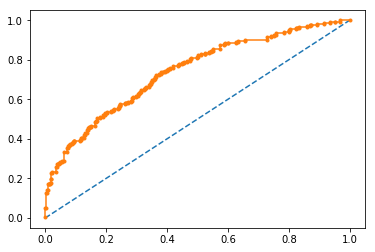

In [96]:
fpr_train_lda, tpr_train_lda, tresholds_train_lda = roc_curve(y_train, lda.predict_proba(X_train)[:,1])
plt.plot([0,1], [0,1], linestyle='--')
plt.plot(fpr_train_lda, tpr_train_lda, marker='.')

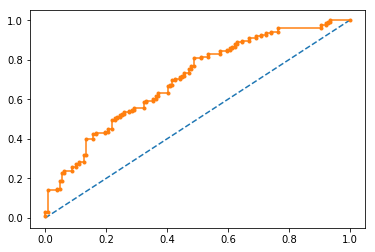

In [97]:
fpr_test_lda, tpr_test_lda, tresholds_test_lda = roc_curve(y_test, lda.predict_proba(X_test)[:,1])
plt.plot([0,1], [0,1], linestyle='--')
plt.plot(fpr_test_lda, tpr_test_lda, marker='.')

### From the above performance metrics, we can see that :
### LDA has better accuracy score, roc_auc_score when compared to logistic regression. 
### The recall and f1 scores for Logistic regression is too low when compared to LDA.
### Hence we can infer that LDA is performing better than logistic regression for this case study.

## 2.4 Inference: Basis on these predictions, what are the insights and recommendations.

### Ans:

### 1) We can observe that, as there is not much correlation between the independent variables and dependent variable, we may need to consider other factors to understand whether one will opt/not opt for Holiday package.
### 2) Foreign could be one factor which may influence an employee of buying holiday package as they show a small positive correlation of 0.25.
### 3) From the above model performance metrics, we can infer that LDA is performing better compared to Logistic Regression.